# Combined Data EDA - SFO Departures, FAA Aircraft, and Hourly Weather

This notebook begins the exploratory analysis of the combined 1-hour prediction-horizon dataset

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 207
PRIMARY_COLOR = "#1f77b4"
SPLIT_COLORS = {
    "train": "#440154",
    "validation": "#31688e",
    "test": "#21918c",
}

### Load the 1-hour prediction-horizon data

The 1-hour dataset is used for this EDA. The same split boundaries can be applied to the other prediction horizons.

In [3]:
HORIZON_HOURS = 1

NOTEBOOK_DIR = Path.cwd()

combined_data_path = NOTEBOOK_DIR / "combined_data" / f"combined_data_{HORIZON_HOURS}h.csv"

datetime_columns = ["date", "scheduled_dep_dt", "actual_dep_dt"]

combined_df = pd.read_csv(combined_data_path, low_memory=False)

for column in datetime_columns:
    combined_df[column] = pd.to_datetime(combined_df[column], errors="raise")

combined_df = combined_df.sort_values("scheduled_dep_dt").reset_index(drop=True)

print(f"Shape: {combined_df.shape}")
print("Scheduled departure range: " f"{combined_df['scheduled_dep_dt'].min()} to {combined_df['scheduled_dep_dt'].max()}")
display(combined_df.head())

Shape: (334086, 32)
Scheduled departure range: 2022-01-01 05:25:00 to 2026-04-30 12:55:00


,date,scheduled_dep_dt,actual_dep_dt,carrier_code,destination_airport,scheduled_elapsed_time_minutes,year,month,day_of_week,is_weekend,...,dew_point_temperature,relative_humidity,altimeter,aircraft_age,week_num,temperature_dewpoint_spread,airport_delay_average_1h,airport_delay_stddev_1h,airport_departures_observed_1h,departure_delay_minutes
0,2022-01-01,2022-01-01 05:25:00,2022-01-01 05:25:00,WN,DEN,145.0,2022.0,1.0,5.0,1,...,5.0,74.0,1014.6,16.0,1,4.4,0.0,0.0,0.0,0.0
1,2022-01-01,2022-01-01 05:55:00,2022-01-01 05:52:00,DL,SLC,118.0,2022.0,1.0,5.0,1,...,5.0,74.0,1014.6,3.0,1,4.4,0.0,0.0,0.0,-3.0
2,2022-01-01,2022-01-01 06:00:00,2022-01-01 06:14:00,DL,ATL,272.0,2022.0,1.0,5.0,1,...,5.0,77.0,1015.6,20.0,1,3.9,0.0,0.0,0.0,14.0
3,2022-01-01,2022-01-01 06:02:00,2022-01-01 05:56:00,UA,LAX,98.0,2022.0,1.0,5.0,1,...,5.0,77.0,1015.6,6.0,1,3.9,0.0,0.0,0.0,-6.0
4,2022-01-01,2022-01-01 06:10:00,2022-01-01 07:51:00,DL,MSP,218.0,2022.0,1.0,5.0,1,...,5.0,77.0,1015.6,24.0,1,3.9,0.0,0.0,0.0,101.0


### Chronological train, validation, and test design

The split uses scheduled departure time, which is known when a prediction is made. The final test period begins on January 1, 2025 and remains outside cross-validation.

- **training:** 2022-2023
- **validation:** 2024
- **final test:** 2025 through April 2026 (the end of the currently available combined data).

In [4]:
VALIDATION_START = pd.Timestamp("2024-01-01")
TEST_START = pd.Timestamp("2025-01-01")

train_mask = combined_df["scheduled_dep_dt"] < VALIDATION_START
validation_mask = combined_df["scheduled_dep_dt"].between(
    VALIDATION_START, TEST_START, inclusive="left"
)
test_mask = combined_df["scheduled_dep_dt"] >= TEST_START

combined_train_df = combined_df.loc[train_mask].copy().reset_index(drop=True)
combined_validation_df = combined_df.loc[validation_mask].copy().reset_index(drop=True)
combined_test_df = combined_df.loc[test_mask].copy().reset_index(drop=True)

assert train_mask.astype(int).add(validation_mask.astype(int)).add(test_mask.astype(int)).eq(1).all()
assert all(
    not split_df.empty
    for split_df in [combined_train_df, combined_validation_df, combined_test_df]
)

splits = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [
            len(combined_train_df),
            len(combined_validation_df),
            len(combined_test_df),
        ],
        "start_date": [
            combined_train_df["scheduled_dep_dt"].min(),
            combined_validation_df["scheduled_dep_dt"].min(),
            combined_test_df["scheduled_dep_dt"].min(),
        ],
        "end_date": [
            combined_train_df["scheduled_dep_dt"].max(),
            combined_validation_df["scheduled_dep_dt"].max(),
            combined_test_df["scheduled_dep_dt"].max(),
        ],
    }
)

splits["percent_of_rows"] = (100 * splits["rows"] / len(combined_df)).round(2)

display(splits)

,split,rows,start_date,end_date,percent_of_rows
0,train,151575,2022-01-01 05:25:00,2023-12-31 23:59:00,45.37
1,validation,84531,2024-01-01 00:20:00,2024-12-31 23:55:00,25.30
2,test,97980,2025-01-01 05:00:00,2026-04-30 12:55:00,29.33


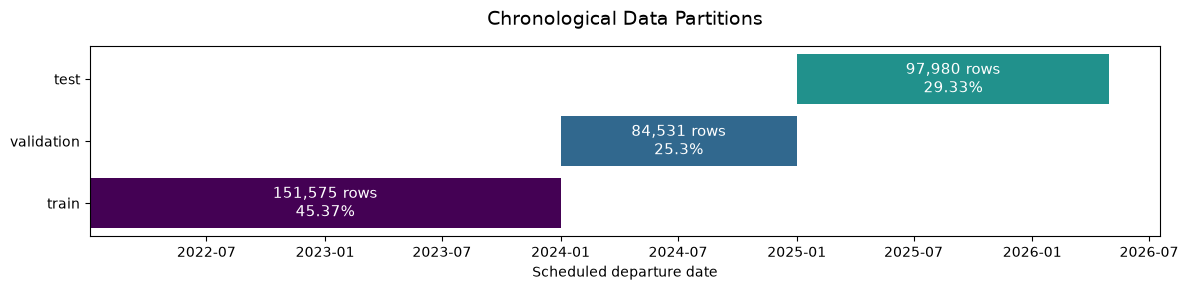

In [5]:
fig, ax = plt.subplots(figsize=(12, 3))

for _, row in splits.iterrows():
    start_date = row["start_date"]
    end_date = row["end_date"]
    split_name = row["split"]
    ax.barh(
        split_name,
        width=(end_date - start_date).total_seconds() / 86_400,
        left=start_date,
        color=SPLIT_COLORS[split_name],
    )
    ax.text(
        x=start_date + (end_date - start_date) / 2,
        y=split_name,
        s=f"{row['rows']:,} rows\n{row['percent_of_rows']}%",
        va="center",
        ha="center",
        color="white",
        fontsize=11,
    )

ax.set_xlabel("Scheduled departure date")
ax.set_title("Chronological Data Partitions", fontsize=14, pad=15)
plt.tight_layout()
plt.show()